In [1]:
import dask
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmcrameri as cm
import os
import matplotlib.gridspec as gridspec  
import warnings
from cmcrameri import cm

warnings.filterwarnings("ignore", category=FutureWarning)
dask.config.set(**{'array.slicing.split_large_chunks': True})

In [2]:
import babet as bb
import atmicp

In [3]:
atmicp.Constants.palette

[(0.3411764705882353, 0.5647058823529412, 0.9882352941176471),
 (0.9725490196078431, 0.611764705882353, 0.12549019607843137),
 (0.8941176470588236, 0.1450980392156863, 0.21176470588235294),
 (0.5882352941176471, 0.2901960784313726, 0.5450980392156862),
 (0.611764705882353, 0.611764705882353, 0.6313725490196078),
 (0.47843137254901963, 0.12941176470588237, 0.8666666666666667)]

In [4]:
def diff_with_offset(a, b, dim="inidate", offset=1):
    return a.isel({dim: slice(0, -offset)}) - b.isel({dim: slice(offset, None)})

# Import data

In [5]:
base_dir = '/gf5/predict/AWH019_ERMIS_ATMICP/test_ATMICP/INTEGRATIONS/GLO100/sfc/'

# q and t data PI
tmp1 = xr.open_dataset(base_dir + 'cf/b2ui_2022-02-11.nc').expand_dims({'number': [0]})
tmp2 = xr.open_dataset(base_dir + 'pf/b2ui_2022-02-11.nc').expand_dims({'number': [1]})
q_and_t = xr.concat([tmp1, tmp2], dim='number')

# prognostic var data PI
tmp1 = xr.open_dataset(base_dir + 'cf/b2up_2022-02-11.nc').expand_dims({'number': [0]})
tmp2 = xr.open_dataset(base_dir + 'pf/b2up_2022-02-11.nc').expand_dims({'number': [1]})
prognostic_vars = xr.concat([tmp1, tmp2], dim='number')

# vanilla PI
tmp1 = xr.open_dataset(base_dir + 'cf/b2ur_2022-02-11.nc').expand_dims({'number': [0]})
tmp2 = xr.open_dataset(base_dir + 'pf/b2ur_2022-02-11.nc').expand_dims({'number': [1]})
vanilla_pi = xr.concat([tmp1, tmp2], dim='number')

# previous PI, uniterated
tmp1 = xr.open_dataset(base_dir + 'cf/b2ui_2022-02-10.nc').expand_dims({'number': [0]})
tmp2 = xr.open_dataset(base_dir + 'pf/b2ui_2022-02-10.nc').expand_dims({'number': [1]})
prev_pi = xr.concat([tmp1, tmp2], dim='number')

# normal current forecast
tmp1 = xr.open_dataset(base_dir + 'cf/b2uk_2022-02-11.nc').expand_dims({'number': [0]})
tmp2 = xr.open_dataset(base_dir + 'pf/b2uk_2022-02-11.nc').expand_dims({'number': [1]})
normal = xr.concat([tmp1, tmp2], dim='number')

# previous current current forecast
tmp1 = xr.open_dataset(base_dir + 'cf/b2uk_2022-02-10.nc').expand_dims({'number': [0]})
tmp2 = xr.open_dataset(base_dir + 'pf/b2uk_2022-02-10.nc').expand_dims({'number': [1]})
prev_normal = xr.concat([tmp1, tmp2], dim='number')

In [6]:
prev_normal

<xarray.Dataset>
Dimensions:    (number: 2, longitude: 360, latitude: 181, time: 3)
Coordinates:
  * number     (number) int64 0 1
  * longitude  (longitude) float32 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
  * latitude   (latitude) float32 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * time       (time) datetime64[ns] 2022-02-10T06:00:00 ... 2022-02-11
Data variables:
    tcwv       (number, time, latitude, longitude) float32 3.137 3.137 ... 1.296
    msl        (number, time, latitude, longitude) float32 1.004e+05 ... 1.01...
    t2m        (number, time, latitude, longitude) float32 246.9 246.9 ... 242.6
Attributes:
    Conventions:  CF-1.6
    history:      2026-02-05 12:34:08 GMT by grib_to_netcdf-2.39.4: /opt/ecmw...

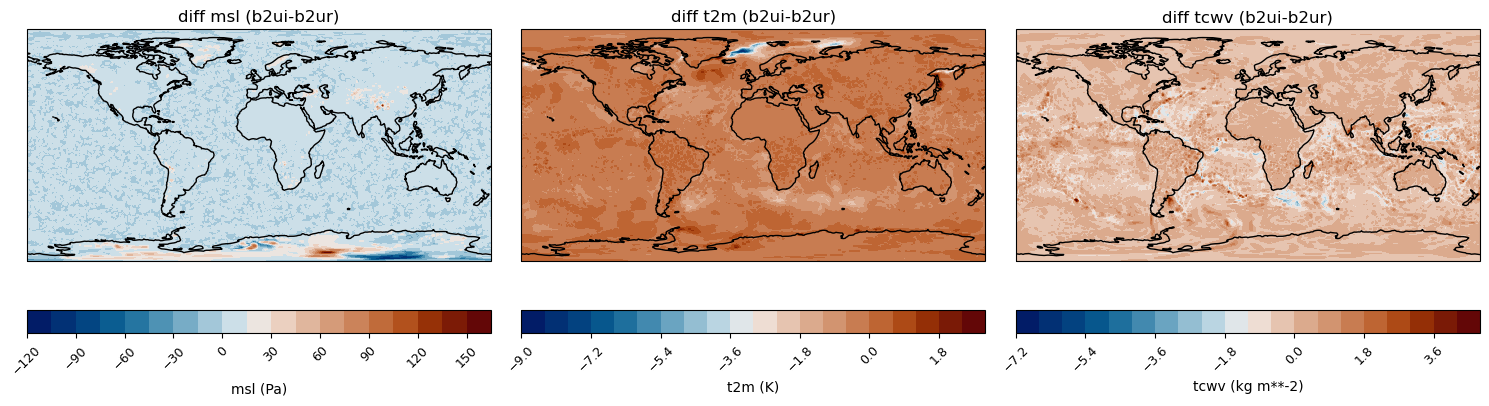

In [8]:
# PI iterating t and q MINUS vanilla PI
fig = plt.figure(figsize=(15, 10))

colourbars = {'t2m': cm.batlow, 'tcwv': cm.davos_r, 'msl': cm.bam}

for v, var in enumerate(['msl', 't2m', 'tcwv'], start=1):
    ax = plt.subplot(1,3,v, projection=ccrs.PlateCarree())

    cf = ax.contourf(
        q_and_t['longitude'],
        q_and_t['latitude'],
        (q_and_t-vanilla_pi)[var].sel(time='2022-02-11T00:00:00').mean(dim='number'), cmap=cm.vik, levels=21)

    # colorbar etc
    cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05)
    cbar.set_label(rf'{var} ({q_and_t[var].units})')
    cbar.ax.tick_params(labelrotation=45, labelsize=9)
    ax.set_title(f'diff {var} (b2ui-b2ur)')
    ax.coastlines()

plt.tight_layout()
plt.show()